# Module import

In [1]:
import numpy as np      
from scipy import ndimage        
from netCDF4 import Dataset        
from scipy.ndimage import zoom, gaussian_filter, label                 
from skimage.transform import resize


import matplotlib.pyplot as plt 
import matplotlib.colors as mcolors   
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.patches import Circle, Rectangle
from matplotlib.legend_handler import HandlerPatch

import cartopy.crs as ccrs                              
import cartopy.feature as cfeature     
import cartopy.io.shapereader as shpreader
import sys
sys.path.insert(1, "/home/users/mendrika/SSA/SA/module")
import snflics #type: ignore

import torch 
import torch.nn as nn
import os


import warnings
warnings.filterwarnings("ignore")

from datetime import datetime, timedelta

from scipy.spatial import cKDTree
from matplotlib.colors import ListedColormap

In [2]:
sys.path.append("/home/users/mendrika/Object-Based-LSTMConv/notebooks/model/training")
from ncast import Core2MapModel

# Choose nowcast origin and lead time (in hour)

In [3]:
year = "2024"
month = "09"
day = "27"
hour = "17"
minute = "15"

In [4]:
lead_time = 1

# Configurations

## Zambia extent

In [5]:
DISPLAY_LON_MIN = -18.5
DISPLAY_LON_MAX = -4.45
DISPLAY_LAT_MIN = 5.1
DISPLAY_LAT_MAX = 19.5

# Ground truth 

In [6]:
def update_hour(date_dict, hours_to_add, minutes_to_add):
    """
    Add hours and minutes to a datetime dictionary and return the updated dict and a generated file path.

    Args:
        date_dict     (dict): Keys: 'year', 'month', 'day', 'hour', 'minute' as strings, e.g. "01", "23"
        hours_to_add   (int): Number of hours to add.
        minutes_to_add (int): Number of minutes to add.

    Returns:
        tuple:
            - dict: Updated datetime dictionary with all fields as zero-padded strings.
            - str: File path in the format YYYY/MM/YYYYMMDDHHMM.nc
    """
    # Parse the original time
    time_obj = datetime(
        int(date_dict["year"]),
        int(date_dict["month"]),
        int(date_dict["day"]),
        int(date_dict["hour"]),
        int(date_dict["minute"])
    )

    # Add hours
    updated = time_obj + timedelta(hours=hours_to_add, minutes=minutes_to_add)

    # Format updated dictionary
    new_date_dict = {
        "year":   f"{updated.year:04d}",
        "month":  f"{updated.month:02d}",
        "day":    f"{updated.day:02d}",
        "hour":   f"{updated.hour:02d}",
        "minute": f"{updated.minute:02d}"
    }

    # Generate file path
    file_path = f"{new_date_dict['year']}/{new_date_dict['month']}/{new_date_dict['year']}{new_date_dict['month']}{new_date_dict['day']}{new_date_dict['hour']}{new_date_dict['minute']}.nc"

    return {'time': new_date_dict, 'path': file_path}

In [7]:
def load_wavelet_dataset(year, month, day, hour, minute, lead_time):
    nowcast_origin = {"year": year, "month": month, "day": day, "hour": hour, "minute": minute}
    nowcast_lt = update_hour(nowcast_origin, hours_to_add=lead_time, minutes_to_add=0)["time"]

    path = (
        f"/gws/nopw/j04/cocoon/SSA_domain/ch9_wavelet/"
        f"{nowcast_lt['year']}/{nowcast_lt['month']}/"
        f"{nowcast_lt['year']}{nowcast_lt['month']}{nowcast_lt['day']}"
        f"{nowcast_lt['hour']}{nowcast_lt['minute']}.nc"
    )

    with Dataset(path, "r") as ds:
        arr = ds["cores"][:]     # <-- FORCE READ INTO MEMORY
    return arr


# ZCAST

In [8]:
y_min, y_max = 1403, 1914
x_min, x_max = 66, 577

In [9]:
# lat and lon meshgrids
geodata = np.load("/gws/nopw/j04/cocoon/SSA_domain/lat_lon_2268_2080.npz")
lons = geodata["lon"][y_min:y_max+1, x_min:x_max+1]
lats = geodata["lat"][y_min:y_max+1, x_min:x_max+1]

# Dakar lat lon
Dakar_lon = -17.467686
Dakar_lat = 14.716677

In [10]:
def load_zcast_input(year, month, day, hour, minute, lead_time):
    input_path_zcast = f"/work/scratch-nopw2/mendrika/OB/raw/inputs_t0"
    core_input = f"{input_path_zcast}/input-{year}{month}{day}_{hour}{minute}.pt"
    return torch.load(core_input)

In [11]:
ENSEMBLE_DIR = f"/gws/nopw/j04/wiser_ewsa/mrakotomanga/OB/checkpoints/WS/transformer/t{lead_time}"

SCALER_PATH = "/home/users/mendrika/Object-Based-LSTMConv/outputs/scaler/scaler_realcores.pt"

MASK_COL_INDEX = 12
COLS_TO_SCALE = range(4, 12)

# load scaler
scaler = torch.load(SCALER_PATH, weights_only=False)
mu = np.asarray(scaler["mean"])
scale = np.asarray(scaler["scale"])

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

[
    lat, lon,
    lat_min, lat_max,
    lon_min, lon_max,
    tir, size,
    mask, time_lag
]

In [12]:
zcast_input = load_zcast_input(year, month, day, hour, minute, lead_time)

In [13]:
input_tensor = zcast_input["input_tensor"].clone().unsqueeze(0)

In [14]:
input_tensor.shape 

torch.Size([1, 5, 50, 13])

In [15]:
try:
    # load one instance
    zcast_input = load_zcast_input(year, month, day, hour, minute, 0)

    # shape: (5, 50, 13) → add batch dim → (1, 5, 50, 13)
    input_tensor = zcast_input["input_tensor"].clone().unsqueeze(0)

    # remove batch dim for scaling
    X = input_tensor[0]

    # convert to numpy
    X_np = X.numpy()

    # reshape to (250, 13)
    flat = X_np.reshape(-1, X_np.shape[-1])

    # scale all cores (real + padded)
    flat[:, COLS_TO_SCALE] = (flat[:, COLS_TO_SCALE] - mu) / scale

    # reshape back to (5, 50, 13)
    X_scaled = torch.tensor(flat.reshape(X_np.shape), dtype=torch.float32)

    # re-add batch dimension → (1, 5, 50, 13)
    input_scaled = X_scaled.unsqueeze(0)
except:
    print("No input")    

In [16]:
def load_models(ensemble_dir):
    models = []
    for seed in sorted(os.listdir(ensemble_dir)):
        ckpt = os.path.join(ensemble_dir, seed, "best-core2map.ckpt")
        if os.path.exists(ckpt):
            model = Core2MapModel.load_from_checkpoint(ckpt, map_location=DEVICE)
            model.eval().to(DEVICE)
            models.append(model)
            print(f"Loaded {ckpt}")
    return models

In [17]:
def ensemble_predict(models, x):
    preds = []
    with torch.no_grad():
        for model in models:
            pred = torch.sigmoid(model(x)).squeeze(0).squeeze(0)
            preds.append(pred)
    preds = torch.stack(preds)
    mean_pred = preds.mean(dim=0)
    var_pred  = preds.var(dim=0)
    return mean_pred, var_pred

In [18]:
models = load_models(ENSEMBLE_DIR)

Loaded /gws/nopw/j04/wiser_ewsa/mrakotomanga/OB/checkpoints/WS/transformer/t1/seed10/best-core2map.ckpt
Loaded /gws/nopw/j04/wiser_ewsa/mrakotomanga/OB/checkpoints/WS/transformer/t1/seed20/best-core2map.ckpt
Loaded /gws/nopw/j04/wiser_ewsa/mrakotomanga/OB/checkpoints/WS/transformer/t1/seed30/best-core2map.ckpt
Loaded /gws/nopw/j04/wiser_ewsa/mrakotomanga/OB/checkpoints/WS/transformer/t1/seed40/best-core2map.ckpt
Loaded /gws/nopw/j04/wiser_ewsa/mrakotomanga/OB/checkpoints/WS/transformer/t1/seed50/best-core2map.ckpt


In [19]:
torch.backends.mha.set_fastpath_enabled(False)

class MultiheadAttentionCapture(nn.MultiheadAttention):
    def __init__(self, *args, store=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.store = store

    def forward(self, query, key, value, **kwargs):
        out, w = super().forward(
            query,
            key,
            value,
            need_weights=True,
            average_attn_weights=False
        )
        if self.store is not None and isinstance(w, torch.Tensor):
            self.store.append(w.detach().cpu())
        return out, w


def enable_encoder_attn_capture(model, store):
    for i, layer in enumerate(model.transformer.layers):
        old = layer.self_attn

        new = MultiheadAttentionCapture(
            embed_dim=old.embed_dim,
            num_heads=old.num_heads,
            dropout=old.dropout,
            batch_first=getattr(old, "batch_first", False),
            bias=old.in_proj_bias is not None,
            add_zero_attn=old.add_zero_attn,
            kdim=old.kdim,
            vdim=old.vdim,
            store=store,
        )
        new.load_state_dict(old.state_dict())
        layer.self_attn = new
        print(f"Replaced self_attn in layer {i}")

attn_ensemble = []

for idx, model in enumerate(models):
    store = []
    enable_encoder_attn_capture(model, store)

    with torch.no_grad():
        ncast, var = ensemble_predict([model], input_scaled.to(DEVICE))

    attn_ensemble.append(store)
    print(f"Model {idx} captured {len(store)} attention maps")


Replaced self_attn in layer 0
Replaced self_attn in layer 1
Replaced self_attn in layer 2
Replaced self_attn in layer 3
Model 0 captured 4 attention maps
Replaced self_attn in layer 0
Replaced self_attn in layer 1
Replaced self_attn in layer 2
Replaced self_attn in layer 3
Model 1 captured 4 attention maps
Replaced self_attn in layer 0
Replaced self_attn in layer 1
Replaced self_attn in layer 2
Replaced self_attn in layer 3
Model 2 captured 4 attention maps
Replaced self_attn in layer 0
Replaced self_attn in layer 1
Replaced self_attn in layer 2
Replaced self_attn in layer 3
Model 3 captured 4 attention maps
Replaced self_attn in layer 0
Replaced self_attn in layer 1
Replaced self_attn in layer 2
Replaced self_attn in layer 3
Model 4 captured 4 attention maps


In [20]:
def aggregate_ensemble_attention(attn_ensemble):
    """
    Aggregate attention maps across models and heads.
    Returns averaged attention matrices per layer:
       list of tensors [n_tokens, n_tokens]
    """
    if not attn_ensemble:
        print("No attention maps found.")
        return []

    n_models = len(attn_ensemble)
    n_layers = len(attn_ensemble[0])

    att_mean_layers = []

    for layer_idx in range(n_layers):
        layer_maps = []

        for m_idx in range(n_models):
            w = attn_ensemble[m_idx][layer_idx]

            # expected shape: (batch, heads, tokens, tokens)
            if w.dim() == 4:
                w = w[0]            # drop batch → (heads, tokens, tokens)
            elif w.dim() != 3:
                raise ValueError(f"Unexpected attention shape: {w.shape}")

            layer_maps.append(w)

        # stack → (models, heads, tokens, tokens)
        stacked = torch.stack(layer_maps)

        # mean over models and heads → (tokens, tokens)
        att_mean = stacked.mean(dim=(0, 1))
        att_mean_layers.append(att_mean)

    return att_mean_layers


# compute ensemble-averaged attention
att_mean_layers = aggregate_ensemble_attention(attn_ensemble)

# inspect results
for i, att in enumerate(att_mean_layers):
    print(f"Layer {i}: averaged attention shape {tuple(att.shape)}")

Layer 0: averaged attention shape (250, 250)
Layer 1: averaged attention shape (250, 250)
Layer 2: averaged attention shape (250, 250)
Layer 3: averaged attention shape (250, 250)


# Attention score

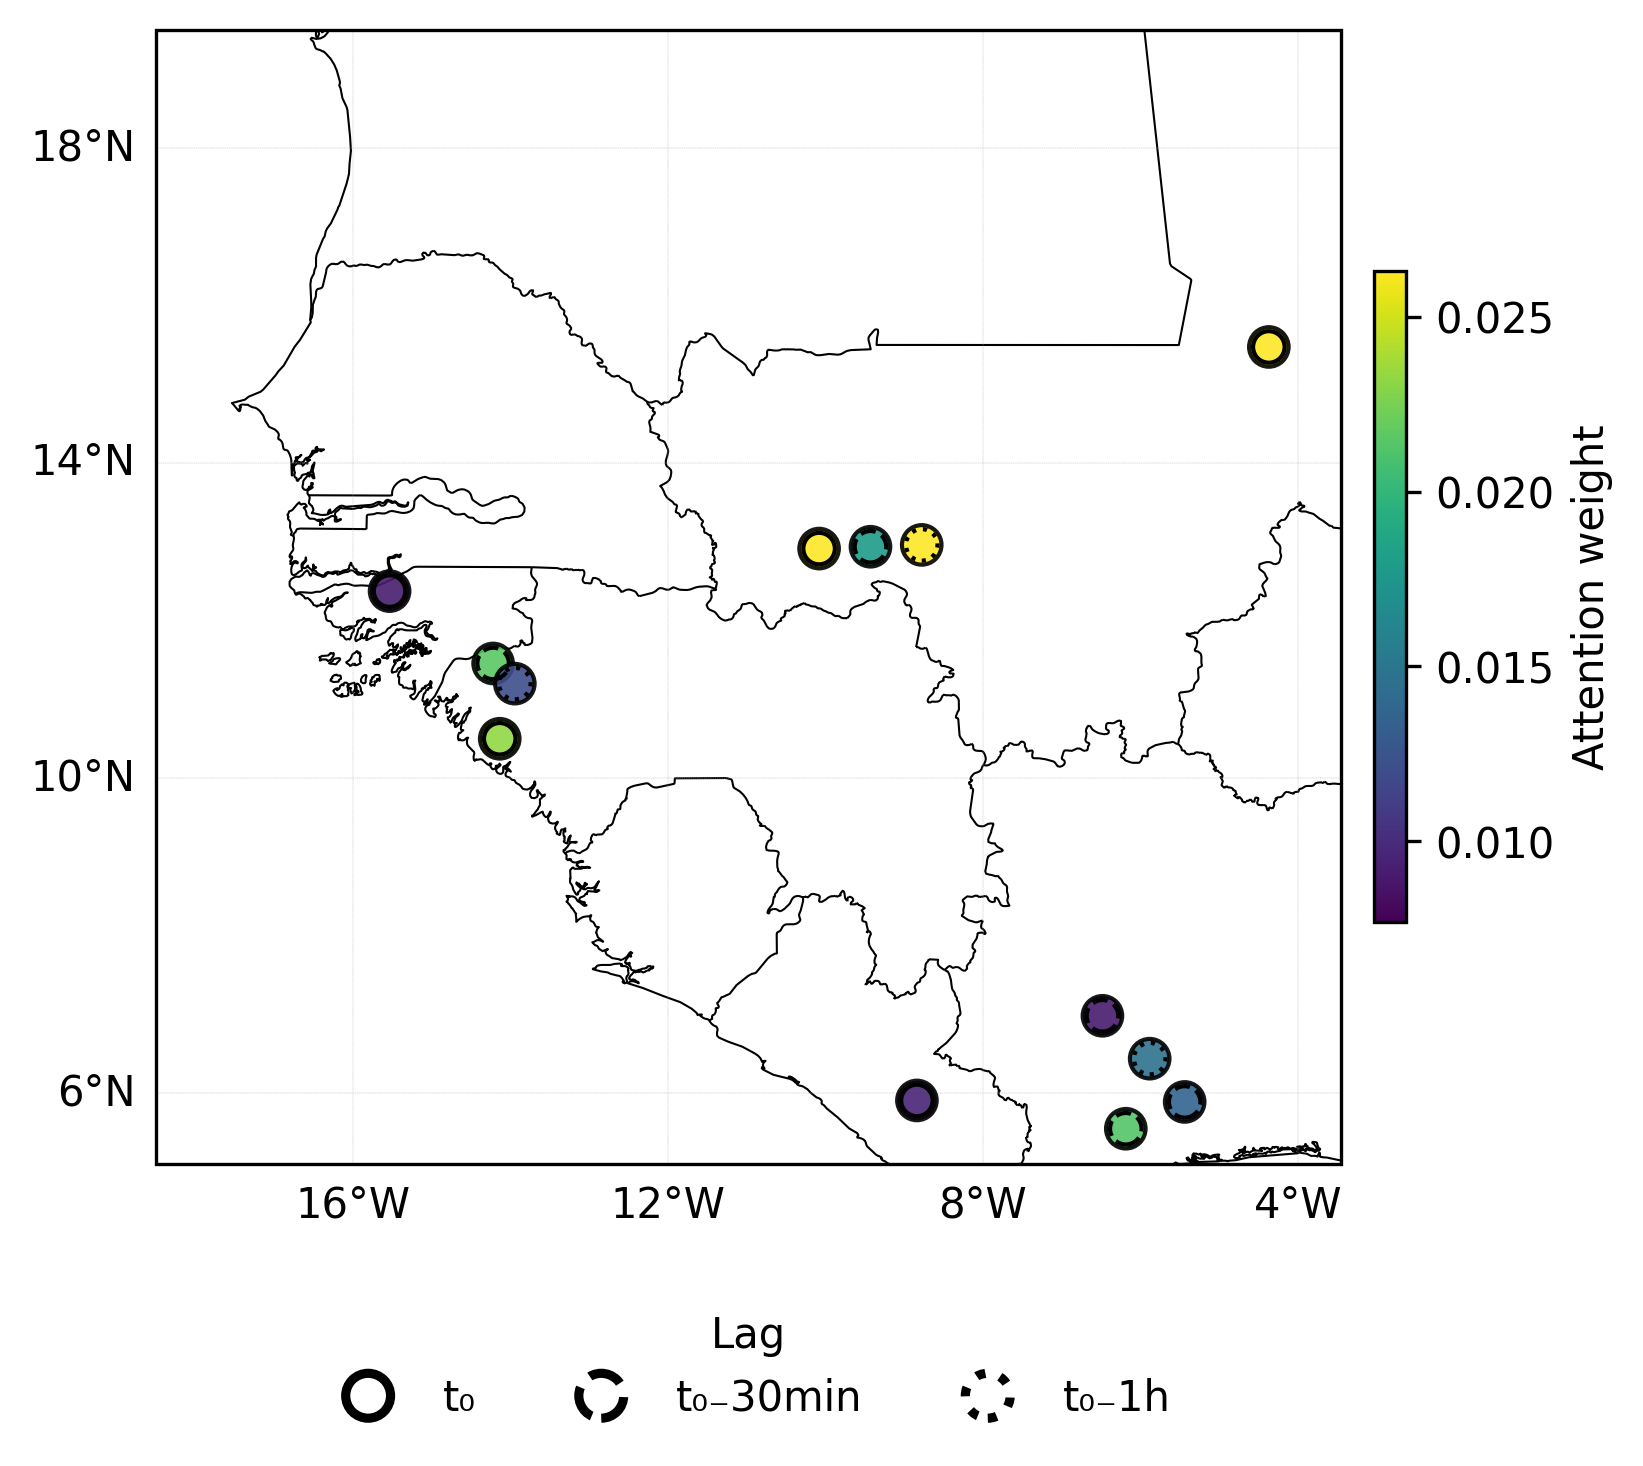

In [84]:
# constants
NB_LAGS = 5
NB_CORES = 50
NB_TOKENS = NB_LAGS * NB_CORES
N_IMPORTANT_CORES = 20

LAT_COL_INDEX = 4
LON_COL_INDEX = 5

lag_minutes = [120, 90, 60, 30, 0]
lag_groups = np.repeat(lag_minutes, NB_CORES)

layer_idx = 0
attn = att_mean_layers[layer_idx].cpu().numpy()

token_importance = attn.mean(axis=0)
top_idx = np.argsort(token_importance)[-N_IMPORTANT_CORES:]

flat = input_scaled.view(1, NB_TOKENS, -1)

lat_norm = flat[0, top_idx, LAT_COL_INDEX].cpu().numpy()
lon_norm = flat[0, top_idx, LON_COL_INDEX].cpu().numpy()
lag = lag_groups[top_idx]
att = token_importance[top_idx]

lat_real = lat_norm * scale[0] + mu[0]
lon_real = lon_norm * scale[1] + mu[1]

mean_att = np.mean(att)
std_att = np.std(att)
vmin = max(0.0, mean_att - std_att)
vmax = mean_att + std_att

norm = Normalize(vmin=vmin, vmax=vmax)
cmap = plt.cm.viridis

fig, ax = plt.subplots(
    figsize=(7, 6),
    subplot_kw={"projection": ccrs.PlateCarree()},
    dpi=300
)

ax.set_extent(
    [DISPLAY_LON_MIN, DISPLAY_LON_MAX+1,
     DISPLAY_LAT_MIN, DISPLAY_LAT_MAX],
    crs=ccrs.PlateCarree()
)

gl = ax.gridlines(
        draw_labels=True, 
        alpha=1, linestyle='--', linewidth=0.1,
        xlocs=np.arange(-16, 6, 4),
        ylocs=np.arange(6, 21, 4),
    )

gl.top_labels = False
gl.right_labels = False    
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.add_feature(cfeature.LAND, facecolor="white")

styles = {
    0:   {"label": "t₀",          "linestyle": "solid"},
    30:  {"label": "t₀₋30min",    "linestyle": "--"},
    60:  {"label": "t₀₋1h",       "linestyle": ":"},
}

for lag_val, style in styles.items():
    sel = lag == lag_val
    if not np.any(sel):
        continue

    ax.scatter(
        lon_real[sel], lat_real[sel],
        c=att[sel], cmap=cmap, norm=norm,
        s=90, transform=ccrs.PlateCarree(),
        alpha=0.9, zorder=3,
        edgecolors="black", linewidth=1.0,
    )

    for lon, lat in zip(lon_real[sel], lat_real[sel]):
        circ = plt.Circle(
            (lon, lat), 0.2,
            transform=ccrs.PlateCarree(),
            fill=False,
            edgecolor="black",
            linewidth=1.0,
            linestyle=style["linestyle"],
            zorder=4,
        )
        ax.add_patch(circ)

sm = ScalarMappable(norm=norm, cmap=cmap)
cbar = fig.colorbar(sm, ax=ax, orientation="vertical", fraction=0.02, pad=0.02)
cbar.set_label("Attention weight")

legend_handles = [
    Circle(
        (0, 0),
        radius=0.5,
        facecolor="none",
        edgecolor="black",
        linewidth=2.2,
        linestyle=style["linestyle"],
        label=style["label"],
    )
    for style in styles.values()
]

def make_hollow_circle(*args, **kwargs):
    legend      = kwargs.get("legend")
    orig_handle = kwargs.get("orig_handle")
    xdescent    = kwargs.get("xdescent")
    ydescent    = kwargs.get("ydescent")
    width       = kwargs.get("width")
    height      = kwargs.get("height")

    center = width/2 - xdescent, height/2 - ydescent

    return Circle(
        center,
        radius=height / 1.3,
        facecolor="none",
        edgecolor=orig_handle.get_edgecolor(),
        linestyle=orig_handle.get_linestyle(),
        linewidth=orig_handle.get_linewidth(),
    )

ax.legend(
    handles=legend_handles,
    title="Lag",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.1),
    ncol=3,
    frameon=False,
    handler_map={Circle: HandlerPatch(patch_func=make_hollow_circle)},
)

plt.subplots_adjust(bottom=0.25)
plt.show()

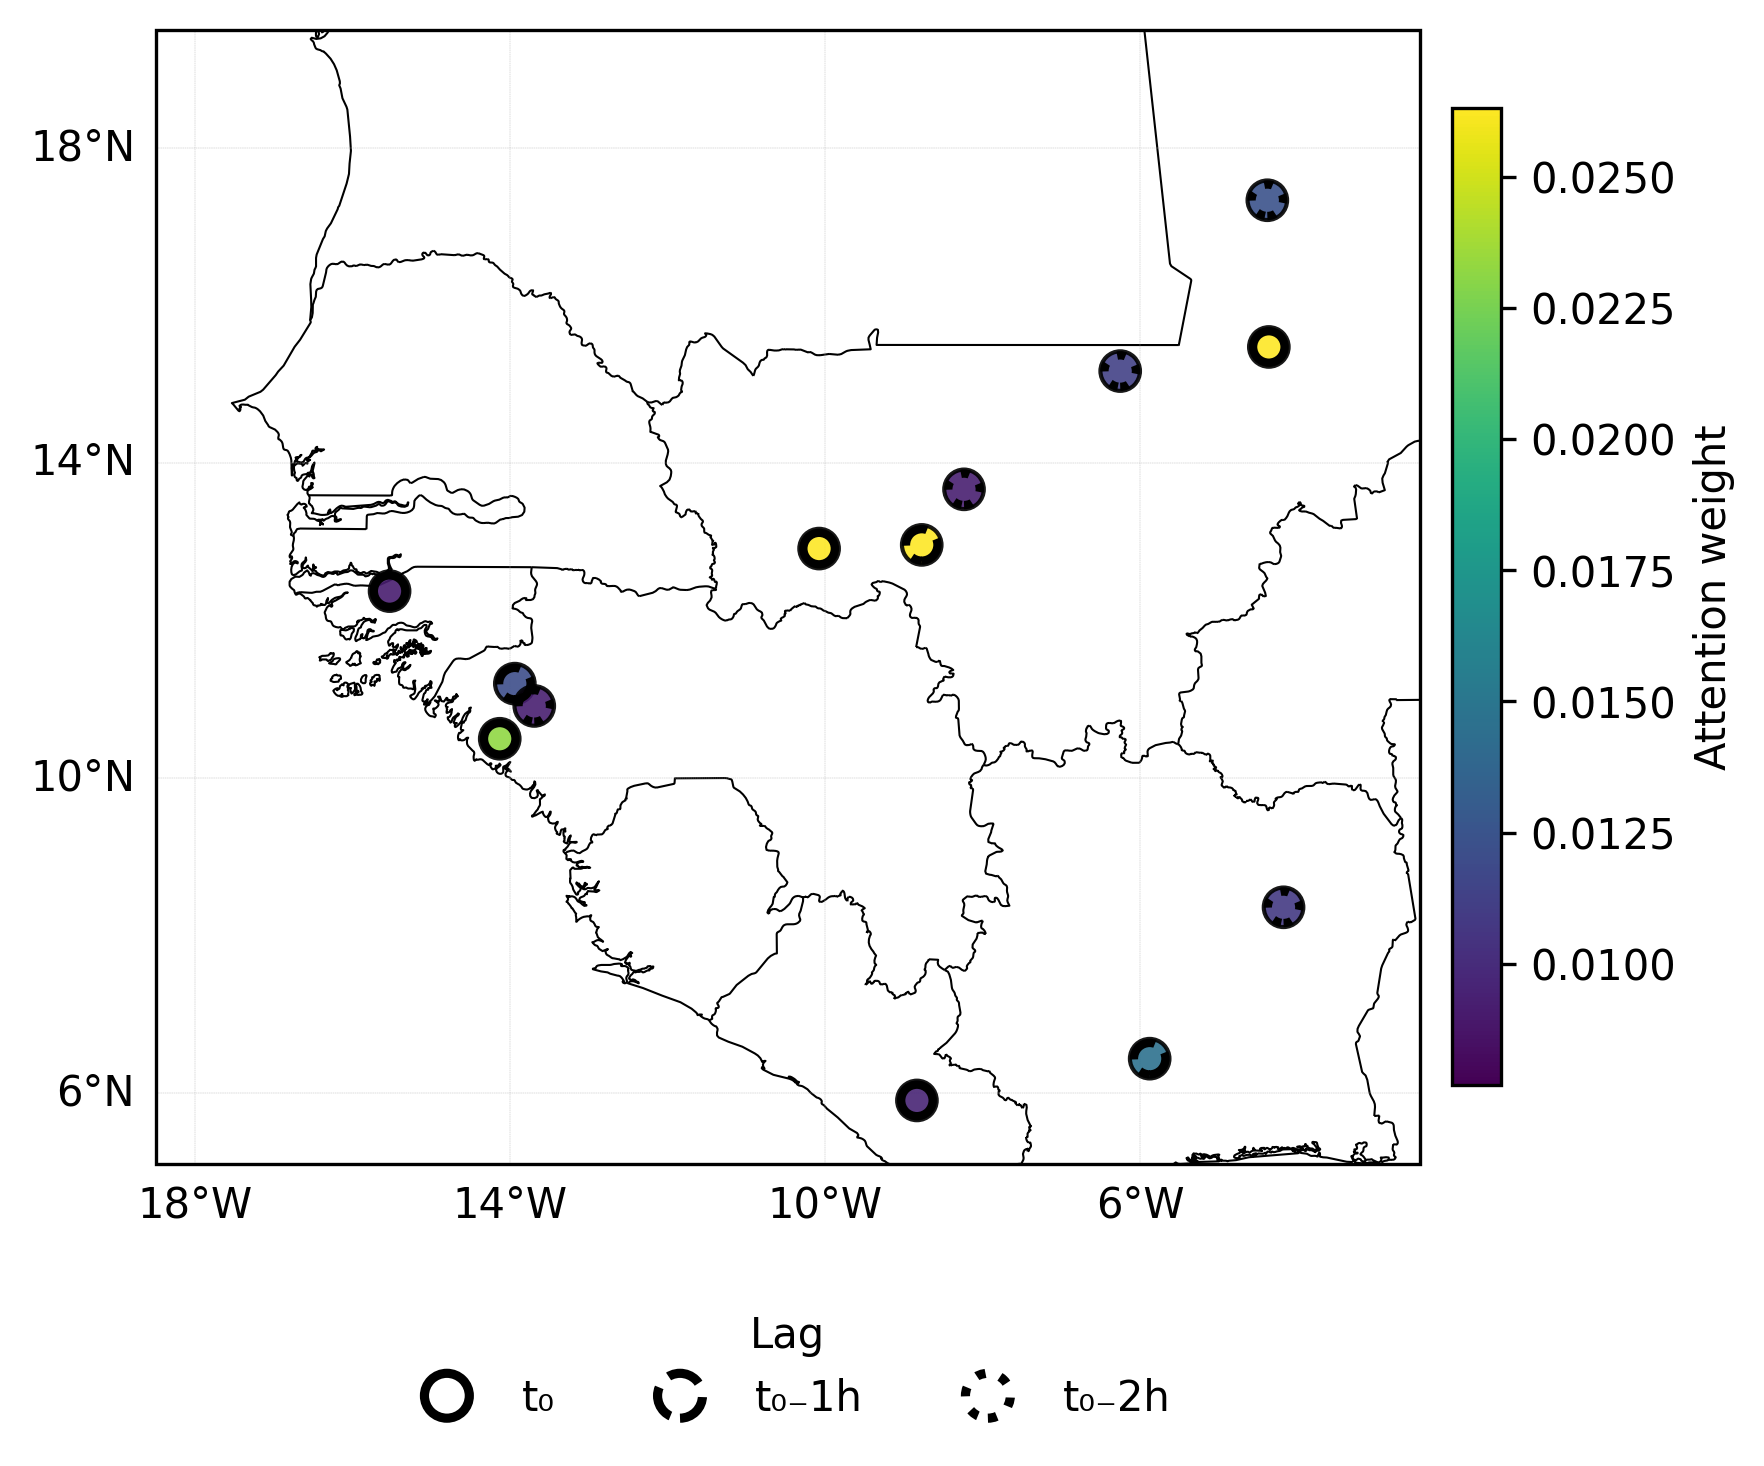

In [69]:
# constants
NB_LAGS = 5
NB_CORES = 50
NB_TOKENS = NB_LAGS * NB_CORES
N_IMPORTANT_CORES = 20

LAT_COL_INDEX = 4
LON_COL_INDEX = 5

lag_minutes = [120, 90, 60, 30, 0]
lag_groups = np.repeat(lag_minutes, NB_CORES)

layer_idx = 0
attn = att_mean_layers[layer_idx].cpu().numpy()

token_importance = attn.mean(axis=0)
top_idx = np.argsort(token_importance)[-N_IMPORTANT_CORES:]

flat = input_scaled.view(1, NB_TOKENS, -1)

lat_norm = flat[0, top_idx, LAT_COL_INDEX].cpu().numpy()
lon_norm = flat[0, top_idx, LON_COL_INDEX].cpu().numpy()
lag = lag_groups[top_idx]
att = token_importance[top_idx]

lat_real = lat_norm * scale[0] + mu[0]
lon_real = lon_norm * scale[1] + mu[1]

mean_att = np.mean(att)
std_att = np.std(att)
vmin = max(0.0, mean_att - std_att)
vmax = mean_att + std_att

norm = Normalize(vmin=vmin, vmax=vmax)
cmap = plt.cm.viridis

fig, ax = plt.subplots(
    figsize=(7, 6),
    subplot_kw={"projection": ccrs.PlateCarree()},
    dpi=300
)

ax.set_extent(
    [DISPLAY_LON_MIN, DISPLAY_LON_MAX+2,
     DISPLAY_LAT_MIN, DISPLAY_LAT_MAX],
    crs=ccrs.PlateCarree()
)


gl = ax.gridlines(
        draw_labels=True, 
        alpha=1, linestyle='--', linewidth=0.1,
        xlocs=np.arange(-18, 6, 4),
        ylocs=np.arange(6, 21, 4),
    )

gl.top_labels = False
gl.right_labels = False    
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.add_feature(cfeature.LAND, facecolor="white")

# Only keep 0, 60, 120 minutes
styles = {
    0:   {"label": "t₀",    "linestyle": "solid"},
    60:  {"label": "t₀₋1h",  "linestyle": "--"},
    120: {"label": "t₀₋2h",  "linestyle": ":"},
}

for lag_val, style in styles.items():
    sel = lag == lag_val
    if not np.any(sel):
        continue

    ax.scatter(
        lon_real[sel], lat_real[sel],
        c=att[sel], cmap=cmap, norm=norm,
        s=90, transform=ccrs.PlateCarree(),
        alpha=0.9, zorder=3,
        edgecolors="black", linewidth=1.0,
    )

    for lon, lat in zip(lon_real[sel], lat_real[sel]):
        circ = plt.Circle(
            (lon, lat), 0.2,
            transform=ccrs.PlateCarree(),
            fill=False,
            edgecolor="black",
            linewidth=2.0,
            linestyle=style["linestyle"],
            zorder=4,
        )
        ax.add_patch(circ)

sm = ScalarMappable(norm=norm, cmap=cmap)
cbar = fig.colorbar(sm, ax=ax, orientation="vertical", fraction=0.03, pad=0.02)
cbar.set_label("Attention weight")

legend_handles = [
    Circle(
        (0, 0),
        radius=0.5,
        facecolor="none",
        edgecolor="black",
        linewidth=2.2,
        linestyle=style["linestyle"],
        label=style["label"],
    )
    for style in styles.values()
]

def make_hollow_circle(*args, **kwargs):
    legend      = kwargs.get("legend")
    orig_handle = kwargs.get("orig_handle")
    xdescent    = kwargs.get("xdescent")
    ydescent    = kwargs.get("ydescent")
    width       = kwargs.get("width")
    height      = kwargs.get("height")

    center = width/2 - xdescent, height/2 - ydescent

    return Circle(
        center,
        radius=height / 1.3,
        facecolor="none",
        edgecolor=orig_handle.get_edgecolor(),
        linestyle=orig_handle.get_linestyle(),
        linewidth=orig_handle.get_linewidth(),
    )

ax.legend(
    handles=legend_handles,
    title="Lag",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.1),
    ncol=3,
    frameon=False,
    handler_map={Circle: HandlerPatch(patch_func=make_hollow_circle)},
)

plt.subplots_adjust(bottom=0.25)
plt.show()


# Visualisation - Important Storms

In [22]:
frames = {
    "t₀−2h": load_wavelet_dataset(year, month, day, hour, minute, -2)[0, y_min:y_max+1, x_min:x_max+1] != 0,
    "t₀−1h": load_wavelet_dataset(year, month, day, hour, minute, -1)[0, y_min:y_max+1, x_min:x_max+1] != 0,
    "t₀":    load_wavelet_dataset(year, month, day, hour, minute,  0)[0, y_min:y_max+1, x_min:x_max+1] != 0,
}
ground_truth = load_wavelet_dataset(year, month, day, hour, minute, lead_time)[0, y_min:y_max+1, x_min:x_max+1] != 0


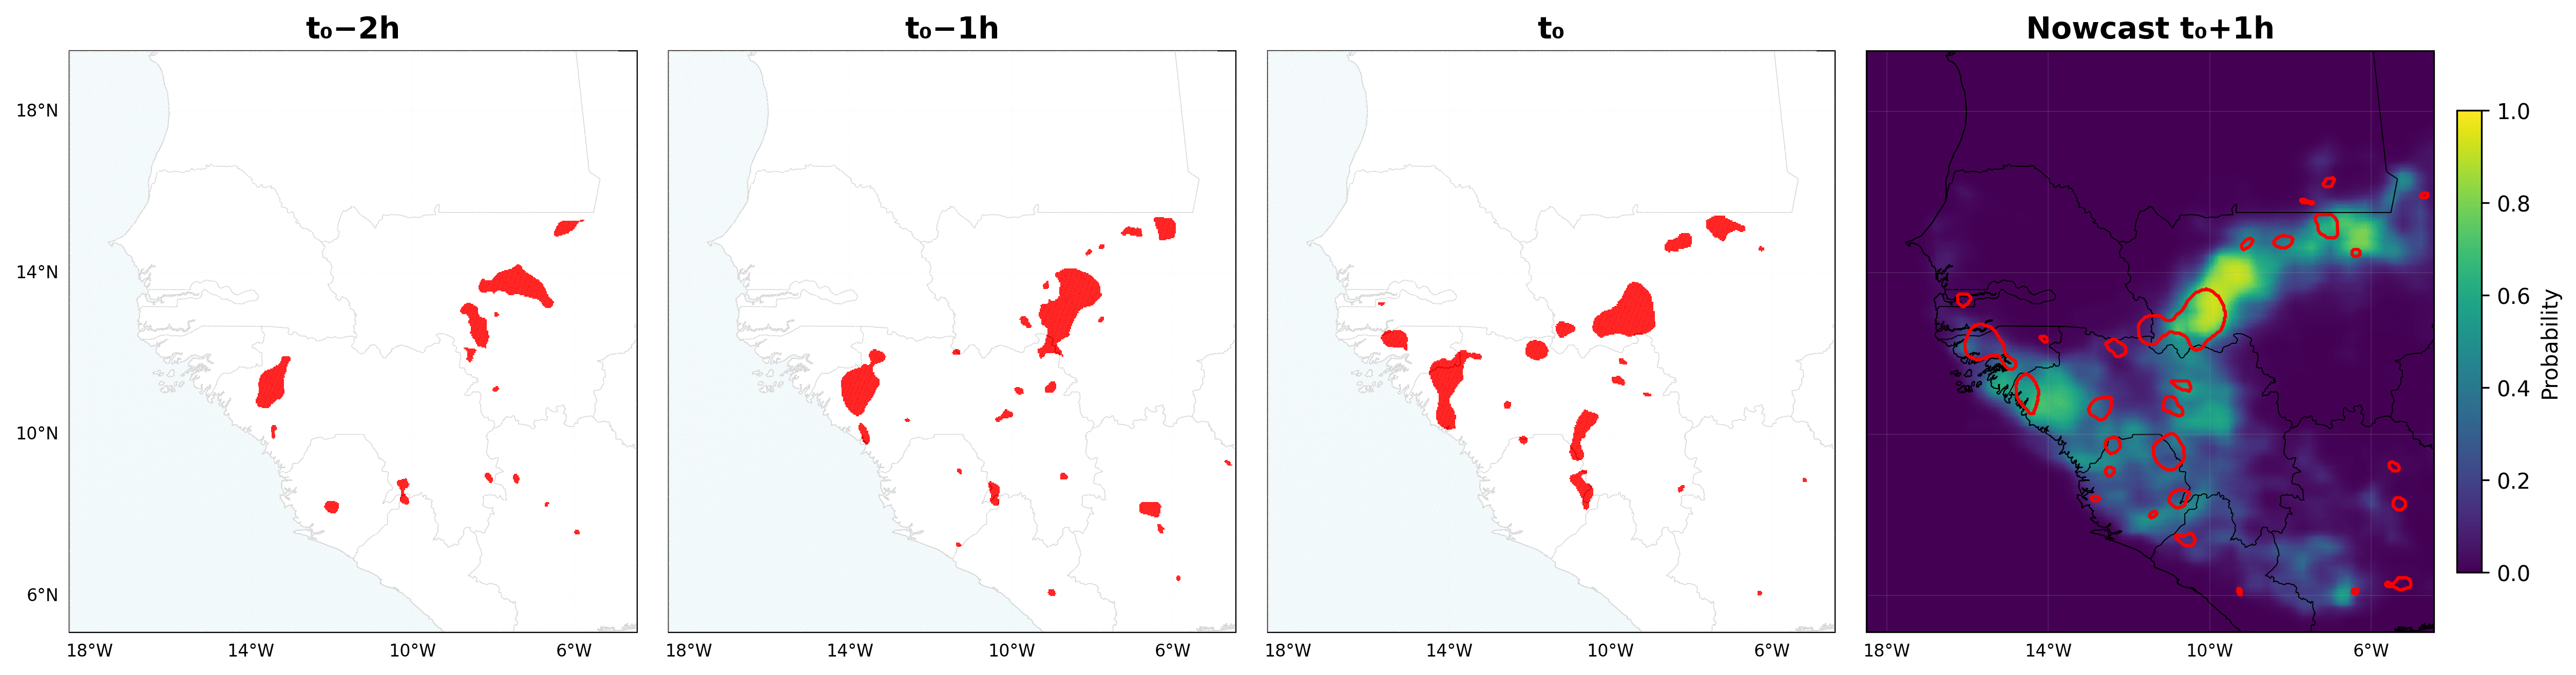

In [49]:
frames = {
    "t₀−2h": load_wavelet_dataset(year, month, day, hour, minute, -2)[0, y_min:y_max+1, x_min:x_max+1] != 0,
    "t₀−1h": load_wavelet_dataset(year, month, day, hour, minute, -1)[0, y_min:y_max+1, x_min:x_max+1] != 0,
    "t₀":    load_wavelet_dataset(year, month, day, hour, minute,  0)[0, y_min:y_max+1, x_min:x_max+1] != 0,
}
ground_truth = load_wavelet_dataset(year, month, day, hour, minute, lead_time)[0, y_min:y_max+1, x_min:x_max+1] != 0


extent = [DISPLAY_LON_MIN, DISPLAY_LON_MAX, DISPLAY_LAT_MIN, DISPLAY_LAT_MAX]

fig, axes = plt.subplots(
    1, 4, figsize=(16, 5),
    subplot_kw={'projection': ccrs.PlateCarree()},
    dpi=300
)

titles = ["t₀−2h", "t₀−1h", "t₀", f"Nowcast t₀+{lead_time}h"]
cmap = ListedColormap(["white", "black", "red"])

def setup_map(ax, title):
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND, facecolor='white', edgecolor='black', linewidth=0.4)
    ax.add_feature(cfeature.OCEAN, facecolor='lightblue', zorder=0)
    ax.add_feature(cfeature.COASTLINE, edgecolor='black', linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, edgecolor='black', linewidth=0.4)
    ax.set_title(title, fontsize=14, fontweight='bold')

for i, ax in enumerate(axes):
    setup_map(ax, titles[i])
    gl = ax.gridlines(
            draw_labels=True, 
            alpha=1, linestyle='--', linewidth=0.1,
            xlocs=np.arange(-18, 6, 4),
            ylocs=np.arange(6, 21, 4),
        )
    gl.top_labels = False
    gl.right_labels = False
    gl.left_labels = (i == 0)
    gl.xlabel_style = {'size': 8}
    gl.ylabel_style = {'size': 8}

for ax, (title, mask) in zip(axes[:3], frames.items()):
    display = np.zeros_like(mask, dtype=int)
    display[mask] = 2  # red = storm region

    ax.pcolormesh(
        lons, lats, display,
        transform=ccrs.PlateCarree(),
        cmap=cmap, vmin=0, vmax=2,
        alpha=0.85, zorder=3
    )

ax = axes[3]
setup_map(ax, f"Nowcast t₀+{lead_time}h")

NCAST_masked = np.ma.masked_where(ncast <= 0, ncast)
NCAST_masked = np.squeeze(NCAST_masked)

im = ax.pcolormesh(
    lons, lats, NCAST_masked,
    cmap='viridis', vmin=0, vmax=1,
    transform=ccrs.PlateCarree(), zorder=1
)

gt_smooth = gaussian_filter(ground_truth.astype(float), sigma=0.4)
ax.contour(
    lons, lats, gt_smooth,
    levels=[0.5], colors='red', linewidths=1.5,
    linestyles='-',
    transform=ccrs.PlateCarree(), zorder=5
)

cax = fig.add_axes([1, 0.2, 0.01, 0.6])  # [left, bottom, width, height]
fig.colorbar(im, cax=cax, label="Probability")


plt.tight_layout()
plt.show()

# Visualisation- Change Colours of Important Storms

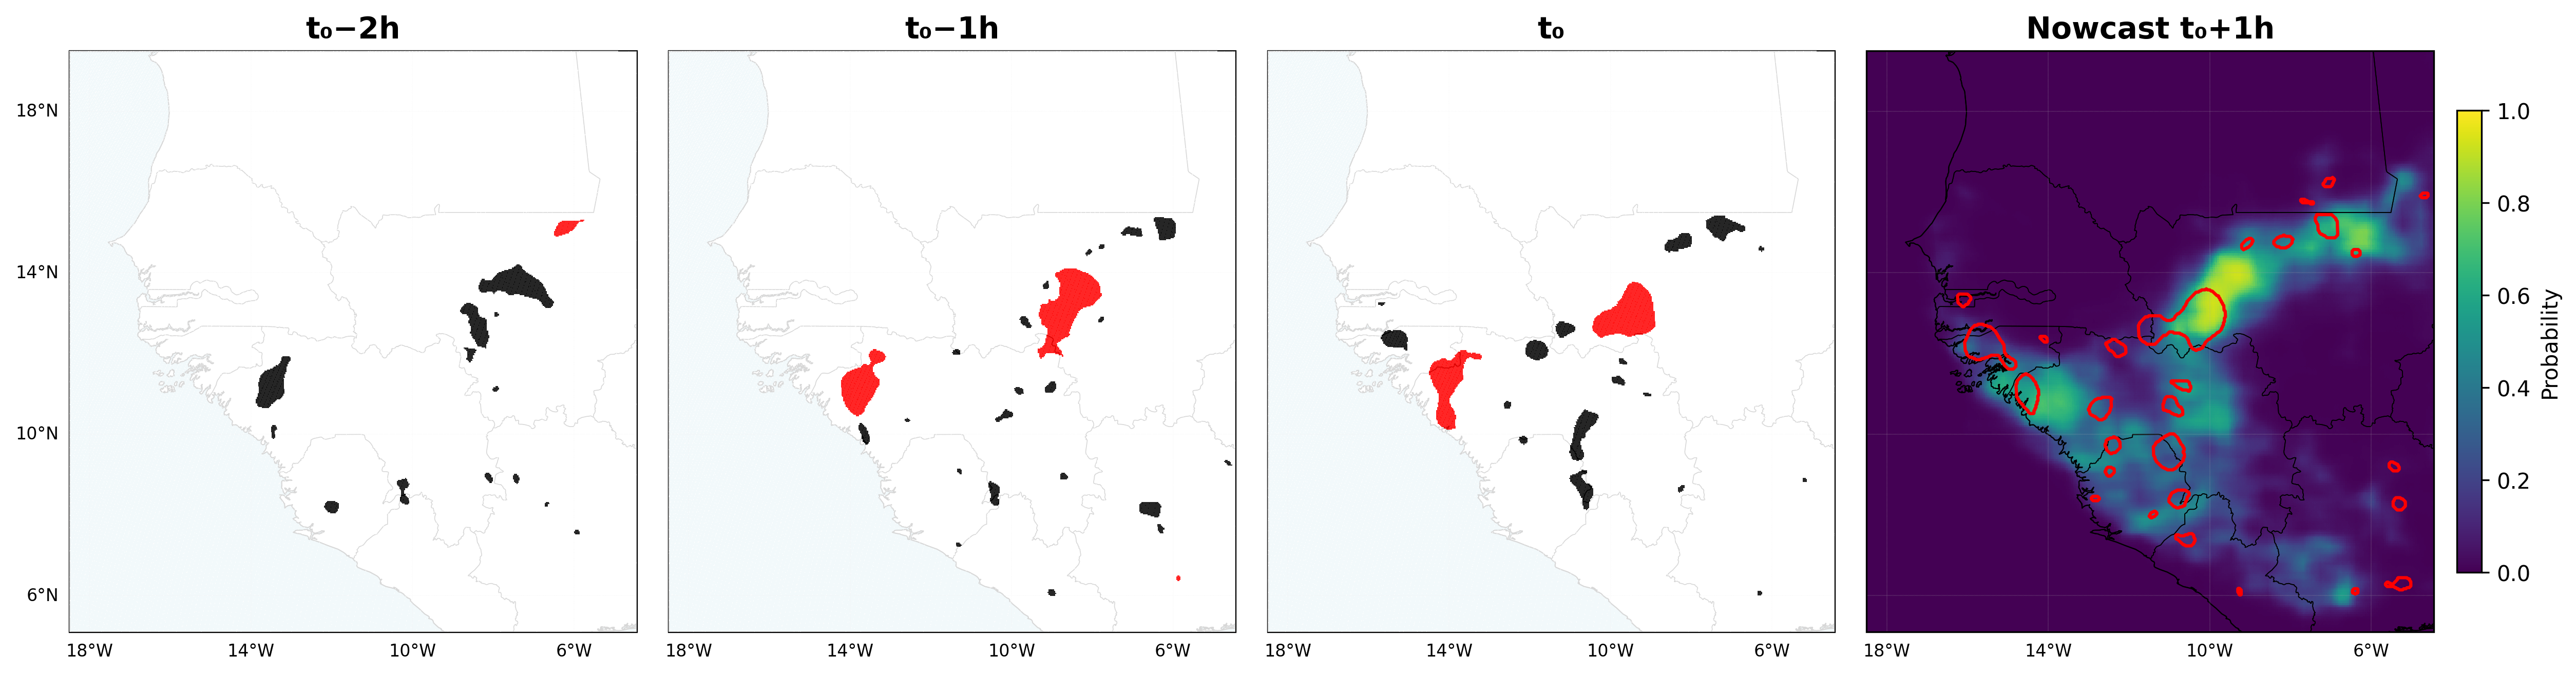

In [50]:
N_IMPORTANT_CORES = 30
ATT_THRESHOLD = 0.01
DIST_THRESHOLD = 0.2

grid_points = np.c_[lons.ravel(), lats.ravel()]
tree = cKDTree(grid_points)

att_values, lat_vals, lon_vals, lag_vals = [], [], [], []

att_layer = att_mean_layers[layer_idx].cpu().numpy()   # (tokens, tokens)
token_importance = att_layer.mean(axis=0)              # (tokens,)

# Identify important tokens
top_idx = np.argsort(token_importance)[-N_IMPORTANT_CORES:]

flat = input_tensor.view(1, NB_TOKENS, -1)

lat_norm = flat[0, top_idx, LAT_COL_INDEX].cpu().numpy()
lon_norm = flat[0, top_idx, LON_COL_INDEX].cpu().numpy()
lag = lag_groups[top_idx]

lat_real = lat_norm * scale[0] + mu[0]
lon_real = lon_norm * scale[1] + mu[1]

att_values = token_importance[top_idx]
lat_vals = lat_real
lon_vals = lon_real
lag_vals = lag

important_per_lag = {}
for lag_val, obs_mask in zip([120, 60, 0], frames.values()):
    labelled_storms, n_storms = label(obs_mask)
    important_mask = np.zeros_like(obs_mask, dtype=bool)
    sel = (lag_vals == lag_val) & (att_values > ATT_THRESHOLD)
    if np.any(sel):
        pts = np.c_[lon_vals[sel], lat_vals[sel]]
        dist, idx = tree.query(pts, k=1)
        valid = dist < DIST_THRESHOLD
        if np.any(valid):
            hit_labels = np.unique(labelled_storms.ravel()[idx[valid]])
            hit_labels = hit_labels[hit_labels > 0]
            important_mask = np.isin(labelled_storms, hit_labels)
    important_per_lag[lag_val] = important_mask

frames = {
    "t₀−2h": load_wavelet_dataset(year, month, day, hour, minute, -2)[0, y_min:y_max+1, x_min:x_max+1] != 0,
    "t₀−1h": load_wavelet_dataset(year, month, day, hour, minute, -1)[0, y_min:y_max+1, x_min:x_max+1] != 0,
    "t₀":    load_wavelet_dataset(year, month, day, hour, minute,  0)[0, y_min:y_max+1, x_min:x_max+1] != 0,
}
ground_truth = load_wavelet_dataset(year, month, day, hour, minute, lead_time)[0, y_min:y_max+1, x_min:x_max+1] != 0

extent = [DISPLAY_LON_MIN, DISPLAY_LON_MAX, DISPLAY_LAT_MIN, DISPLAY_LAT_MAX]

fig, axes = plt.subplots(
    1, 4, figsize=(16, 5),
    subplot_kw={'projection': ccrs.PlateCarree()},
    dpi=300
)

titles = ["t₀−2h", "t₀−1h", "t₀", f"Nowcast t₀+{lead_time}h"]
cmap = ListedColormap(["white", "black", "red"])

def setup_map(ax, title):
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND, facecolor='white', edgecolor='black', linewidth=0.4)
    ax.add_feature(cfeature.OCEAN, facecolor='lightblue', zorder=0)
    ax.add_feature(cfeature.COASTLINE, edgecolor='black', linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, edgecolor='black', linewidth=0.4)
    ax.set_title(title, fontsize=14, fontweight='bold')

for i, ax in enumerate(axes):
    setup_map(ax, titles[i])
    gl = ax.gridlines(
            draw_labels=True, 
            alpha=1, linestyle='--', linewidth=0.1,
            xlocs=np.arange(-18, 6, 4),
            ylocs=np.arange(6, 21, 4),
        )
    gl.top_labels = False
    gl.right_labels = False
    gl.left_labels = (i == 0)
    gl.xlabel_style = {'size': 8}
    gl.ylabel_style = {'size': 8}

for ax, (title, mask), lag_val in zip(axes[:3], frames.items(), [120, 60, 0]):
    imp_mask = important_per_lag[lag_val]
    display = np.zeros_like(mask, dtype=int)
    display[mask] = 1
    display[imp_mask] = 2
    ax.pcolormesh(
        lons, lats, display,
        transform=ccrs.PlateCarree(),
        cmap=cmap, vmin=0, vmax=2,
        alpha=0.85, zorder=3
    )

ax = axes[3]
setup_map(ax, f"Nowcast t₀+{lead_time}h")

NCAST_masked = np.ma.masked_where(ncast <= 0, ncast)
NCAST_masked = np.squeeze(NCAST_masked)

im = ax.pcolormesh(
    lons, lats, NCAST_masked,
    cmap='viridis', vmin=0, vmax=1,
    transform=ccrs.PlateCarree(), zorder=1
)

gt_smooth = gaussian_filter(ground_truth.astype(float), sigma=0.4)
ax.contour(
    lons, lats, gt_smooth,
    levels=[0.5], colors='red', linewidths=1.5,
    linestyles='-',
    transform=ccrs.PlateCarree(), zorder=5
)

cax = fig.add_axes([1, 0.2, 0.01, 0.6])  # [left, bottom, width, height]
fig.colorbar(im, cax=cax, label="Probability")

plt.tight_layout()
plt.show()